# HSV and OkLab gradients

HSV is convenient for choosing a color, but equal numeric steps in its hue, saturation, or value are not equal visual steps. This example holds the endpoints of each gradient fixed and compares interpolation in HSV with interpolation in OkLab.

Each row compares two separate images with the same endpoints. Hue changes from red to blue, saturation changes from white to blue, and value changes from black to yellow. The HSV image interpolates HSV components directly. The OkLab image converts the two endpoint colors to OkLab, interpolates `L`, `a`, and `b`, then converts the result back to sRGB.

In [1]:
from pathlib import Path

import brushcue
from IPython.display import Image, Markdown, display

WIDTH = 600
HEIGHT = 180
OUTPUT_DIRECTORY = Path("/home/dito/dev/monorepo/writing/graphics/chapters/color-formats/assets")
GRADIENTS = (
    ("Hue", 0),
    ("Saturation", 1),
    ("Value", 2),
)
INTERPOLATIONS = (
    ("HSV", 0, "hsv"),
    ("OkLab", 1, "oklab"),
)

ctx = brushcue.Context()

[wgpu] using backend Vulkan — adapter 'NVIDIA GeForce RTX 5070' (DiscreteGpu), driver 'NVIDIA'


In [2]:
FREEFORM_BODY = """
let t = canvas_position.x / 600.0;

var start_hsv = vec3<f32>(0.0, 0.90, 0.90);
var end_hsv = vec3<f32>(0.65, 0.90, 0.90);

if gradient_kind == 1 {
    start_hsv = vec3<f32>(2.0 / 3.0, 0.00, 1.00);
    end_hsv = vec3<f32>(2.0 / 3.0, 1.00, 1.00);
}

if gradient_kind == 2 {
    start_hsv = vec3<f32>(0.16, 0.90, 0.00);
    end_hsv = vec3<f32>(0.16, 0.90, 1.00);
}

if interpolation_mode == 0 {
    return vec4<f32>(hsv_to_srgb(mix(start_hsv, end_hsv, t)), 1.0);
}

let start_oklab = linear_srgb_to_oklab(srgb_to_linear(hsv_to_srgb(start_hsv)));
let end_oklab = linear_srgb_to_oklab(srgb_to_linear(hsv_to_srgb(end_hsv)));
let rgb = linear_to_srgb(oklab_to_linear_srgb(mix(start_oklab, end_oklab, t)));
return vec4<f32>(rgb, 1.0);
"""

WGSL_HELPERS = """
fn hsv_to_srgb(hsv: vec3<f32>) -> vec3<f32> {
    let rgb = clamp(
        abs(fract(hsv.x + vec3<f32>(0.0, 2.0 / 3.0, 1.0 / 3.0)) * 6.0 - 3.0) - 1.0,
        vec3<f32>(0.0),
        vec3<f32>(1.0),
    );
    return hsv.z * mix(vec3<f32>(1.0), rgb, hsv.y);
}

fn srgb_to_linear(rgb: vec3<f32>) -> vec3<f32> {
    let lo = rgb / 12.92;
    let hi = pow((rgb + 0.055) / 1.055, vec3<f32>(2.4));
    return select(hi, lo, rgb <= vec3<f32>(0.04045));
}

fn linear_to_srgb(rgb: vec3<f32>) -> vec3<f32> {
    let lo = 12.92 * rgb;
    let hi = 1.055 * pow(max(rgb, vec3<f32>(0.0)), vec3<f32>(1.0 / 2.4)) - 0.055;
    return select(hi, lo, rgb <= vec3<f32>(0.0031308));
}

fn linear_srgb_to_oklab(rgb: vec3<f32>) -> vec3<f32> {
    let l = pow(0.4122214708 * rgb.r + 0.5363325363 * rgb.g + 0.0514459929 * rgb.b, 1.0 / 3.0);
    let m = pow(0.2119034982 * rgb.r + 0.6806995451 * rgb.g + 0.1073969566 * rgb.b, 1.0 / 3.0);
    let s = pow(0.0883024619 * rgb.r + 0.2817188376 * rgb.g + 0.6299787005 * rgb.b, 1.0 / 3.0);
    return vec3<f32>(
        0.2104542553 * l + 0.7936177850 * m - 0.0040720468 * s,
        1.9779984951 * l - 2.4285922050 * m + 0.4505937099 * s,
        0.0259040371 * l + 0.7827717662 * m - 0.8086757660 * s,
    );
}

fn oklab_to_linear_srgb(oklab: vec3<f32>) -> vec3<f32> {
    let l = pow(oklab.x + 0.3963377774 * oklab.y + 0.2158037573 * oklab.z, 3.0);
    let m = pow(oklab.x - 0.1055613458 * oklab.y - 0.0638541728 * oklab.z, 3.0);
    let s = pow(oklab.x - 0.0894841775 * oklab.y - 1.2914855480 * oklab.z, 3.0);
    return vec3<f32>(
        4.0767416621 * l - 3.3077115913 * m + 0.2309699292 * s,
        -1.2684380046 * l + 2.6097574011 * m - 0.3413193965 * s,
        -0.0041960863 * l - 0.7034186147 * m + 1.7076147010 * s,
    );
}
"""

## Hue

### HSV

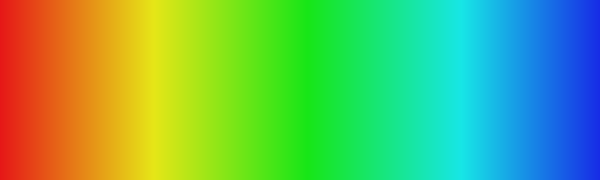

### OkLab

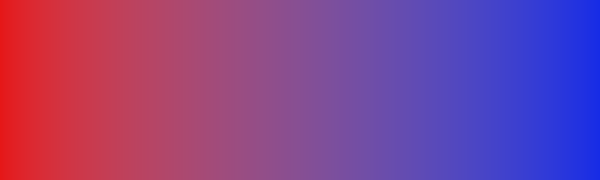

## Saturation

### HSV

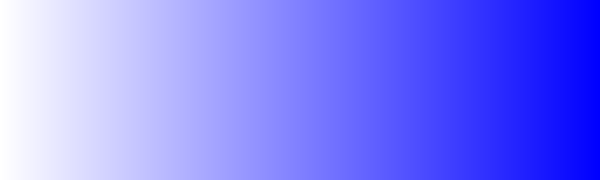

### OkLab

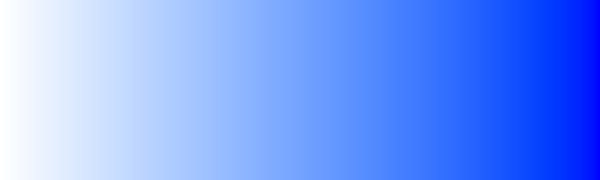

## Value

### HSV

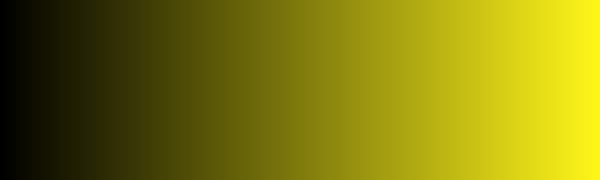

### OkLab

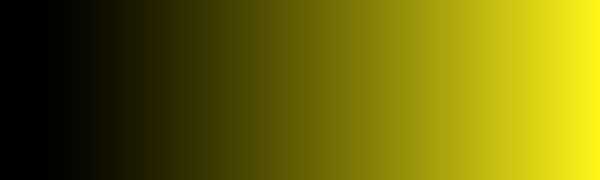

In [3]:
for label, gradient_kind in GRADIENTS:
    display(Markdown(f"## {label}"))
    for interpolation, interpolation_mode, slug in INTERPOLATIONS:
        gradient = brushcue.Composition.freeform_shader(
            FREEFORM_BODY,
            WGSL_HELPERS,
            brushcue.Bounds2f.from_x_y_width_height(0, 0, WIDTH, HEIGHT),
            brushcue.ColorRepresentation.srgb(),
            brushcue.Dictionary.create()
            .add("gradient_kind", gradient_kind)
            .add("interpolation_mode", interpolation_mode),
        )
        png = gradient.execute(ctx).to_image_bytes(ctx)
        (OUTPUT_DIRECTORY / f"{slug}-{label.lower()}-gradient.png").write_bytes(png)
        display(Markdown(f"### {interpolation}"))
        display(Image(data=png))

HSV produces a pronounced bright band through the yellow and green part of the hue ramp. Its saturation and value ramps also change perceived lightness unevenly. Interpolating in OkLab makes the change in lightness and chroma much more even while preserving the same endpoint colors.